# Signature Verification — Batch-Hard Mining and Adaptive Per-Writer Thresholds

This builds directly on 3b — the current best model (fine-tuned EfficientNet-B0, invert
preprocessing, writer-independent split, combined Latin + Devanagari set). 3c adds the two
FAR-targeting techniques I picked out of the literature review:

1. **Online batch-hard triplet mining (training).** I drop 3b's pre-built offline triplets. Each
   batch samples P writers × K images (genuine and their forgeries), and for every genuine anchor
   I mine the hardest positive and hardest negative inside the batch. Because a writer's own
   forgeries are in the batch, the hardest negative is usually a skilled forgery — so training
   focuses exactly where false-accepts come from.
2. **Adaptive per-writer threshold (inference).** I replace the single global EER threshold with a
   per-writer threshold derived from each writer's enrollment references only (their natural
   genuine spread). This targets the NFI FAR≈40% problem, which is a calibration failure, not a
   ranking one. The α multiplier is tuned on validation and applied unchanged to test.

Everything else carries over from 3b unchanged: the fine-tuned EfficientNet-B0 tower, SigNet
invert preprocessing, no-flip augmentation, the writer-independent split, the combined dataset,
the per-script threshold (kept as a baseline), the NFI cross-dataset eval, and the per-epoch Drive
checkpoint.

One honest note: batch-hard mining is genuinely more code than 3b (a PK sampler plus a custom
`train_step`). That complexity is intrinsic to the technique, not decoration — everything outside
the mining loop is kept as simple as 3b.

## 1. Imports

In [ ]:
import os
import json
import math
import random
import csv
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import Model
from keras.layers import Input, Dense, Dropout, Lambda
from keras.applications import EfficientNetB0
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, roc_curve

## 2. Data — Same Combined Set and Split as 3b / NB3

No change to the data: the combined set, read through `manifest.csv`, with the same
writer-independent mixed-script split.

In [ ]:
!git clone https://github.com/goyashek/Signature-forgery-verification.git

DATA_ROOT = 'Signature-forgery-verification/sign_data_combined'
if not os.path.isdir(DATA_ROOT):                      # running locally, not on Colab
    DATA_ROOT = 'sign_data_combined'
MANIFEST = os.path.join(DATA_ROOT, 'manifest.csv')

IMG_H, IMG_W = 155, 220
print('data root:', DATA_ROOT)

fatal: destination path 'Signature-forgery-verification' already exists and is not an empty directory.
data root: Signature-forgery-verification/sign_data_combined


In [ ]:
rows = list(csv.DictReader(open(MANIFEST)))

genuine = defaultdict(list)
forg    = defaultdict(list)
script_of = {}
for r in rows:
    if r['kind'] == 'genuine':
        genuine[r['writer']].append(r['relpath'])
    else:
        forg[r['writer']].append(r['relpath'])
    script_of[r['writer']] = r['script']

writers = sorted(set(genuine) & set(forg))
icdar = [w for w in writers if w.startswith('icdar_')]
bhh   = [w for w in writers if w.startswith('bhh_')]

def writer_num(w):
    return int(w.split('_')[1])

train_w = [w for w in icdar if writer_num(w) <= 40]        + [w for w in bhh if writer_num(w) <= 110]
val_w   = [w for w in icdar if 41 <= writer_num(w) <= 48]  + [w for w in bhh if 111 <= writer_num(w) <= 130]
test_w  = [w for w in icdar if writer_num(w) >= 49]        + [w for w in bhh if writer_num(w) >= 131]

assert not (set(train_w) & set(val_w)),  'train/val writer leak'
assert not (set(train_w) & set(test_w)), 'train/test writer leak'
assert not (set(val_w) & set(test_w)),   'val/test writer leak'

def describe(ws):
    n_icdar = sum(w.startswith('icdar_') for w in ws)
    n_bhh   = sum(w.startswith('bhh_') for w in ws)
    return f"{len(ws)} (icdar {n_icdar} + bhh {n_bhh})"

print('train:', describe(train_w))
print('val:  ', describe(val_w))
print('test: ', describe(test_w))

train: 145 (icdar 35 + bhh 110)
val:   28 (icdar 8 + bhh 20)
test:  51 (icdar 21 + bhh 30)


## 3. Evaluation Pairs

Training uses batch-hard mining (set up below), but evaluation still uses the leak-free
three-recipe pairs from NB3 / 3b, so the global and per-script thresholds stay directly comparable
across notebooks.

In [ ]:
def make_pairs(wset, per_writer, seed=1):
    rng = random.Random(seed)
    wl = sorted(wset)
    out = []
    for w in wl:
        g = genuine[w]
        if len(g) < 2:
            continue
        scr = script_of[w]
        for _ in range(per_writer):                          # match (0)
            a, b = rng.sample(g, 2)
            out.append((a, b, 0, scr))
        for _ in range(per_writer // 2):                     # forgery negative (1)
            if forg.get(w):
                out.append((rng.choice(g), rng.choice(forg[w]), 1, scr))
        for _ in range(per_writer // 2):                     # different-writer negative (1)
            other = rng.choice([x for x in wl if x != w])
            out.append((rng.choice(g), rng.choice(genuine[other]), 1, scr))
    rng.shuffle(out)
    return pd.DataFrame(out, columns=['img1', 'img2', 'label', 'script'])


pairs_val  = make_pairs(val_w,  per_writer=40, seed=2)
pairs_test = make_pairs(test_w, per_writer=40, seed=3)

print('val pairs:', len(pairs_val), '| test pairs:', len(pairs_test))
print('test by script:', pairs_test['script'].value_counts().to_dict())

val pairs: 2240 | test pairs: 4080
test by script: {'devanagari': 2400, 'latin': 1680}


## 4. Image Pipeline — Identical to 3b

Same invert + 3-channel preprocessing and no-flip augmentation as 3b. The only generator I need
here is `PairSequence` for evaluation; training uses the PK sampler below instead.

In [ ]:
_CACHE = {}                                            # relpath -> decoded uint8 grayscale (bg=255)

def load_gray(relpath):
    im = _CACHE.get(relpath)
    if im is None:
        im = cv2.imread(os.path.join(DATA_ROOT, relpath), cv2.IMREAD_GRAYSCALE)
        im = cv2.resize(im, (IMG_W, IMG_H))
        _CACHE[relpath] = im
    return im

def augment(im, rng):
    ang  = rng.uniform(-5, 5)
    tx   = rng.uniform(-0.06, 0.06) * IMG_W
    ty   = rng.uniform(-0.06, 0.06) * IMG_H
    zoom = rng.uniform(0.9, 1.1)
    M = cv2.getRotationMatrix2D((IMG_W / 2, IMG_H / 2), ang, zoom)
    M[0, 2] += tx
    M[1, 2] += ty
    return cv2.warpAffine(im, M, (IMG_W, IMG_H), borderValue=255)   # white fill = background

def to3(im):
    """uint8 HxW grayscale -> inverted float32 HxWx3 (SigNet invert; EfficientNet scales internally)."""
    inv = 255.0 - im.astype('float32')
    return np.repeat(inv[..., None], 3, axis=2)


class PairSequence(keras.utils.Sequence):
    """Eval only: yields (X1, X2); never augments. shuffle=False keeps predict aligned."""
    def __init__(self, frame, batch_size=64, root=DATA_ROOT):
        try:
            super().__init__(workers=4, use_multiprocessing=False, max_queue_size=12)
        except TypeError:
            super().__init__()
        self.f = frame.reset_index(drop=True)
        self.bs = batch_size
        self.root = root

    def __len__(self):
        return math.ceil(len(self.f) / self.bs)

    def _prep(self, relpath):
        im = cv2.imread(os.path.join(self.root, relpath), cv2.IMREAD_GRAYSCALE)
        return to3(cv2.resize(im, (IMG_W, IMG_H)))

    def __getitem__(self, i):
        sub = self.f.iloc[i * self.bs:(i + 1) * self.bs]
        X1 = np.stack([self._prep(p) for p in sub['img1']])
        X2 = np.stack([self._prep(p) for p in sub['img2']])
        return (X1, X2)

## 5. PK Sampler for Batch-Hard Mining

Each batch holds P writers × K images. For each writer I draw `K_GEN` genuine plus `K_FORG` of
their own forgeries, and fill any remaining slots up to K with more genuine. Each image carries
the labels `(writer_index, is_genuine)`, which the custom `train_step` uses to build the
positive/negative masks. Genuine images of a writer are the only valid anchors; forgeries appear
only as negatives (a skilled forgery of A is a hard negative for A).

In [ ]:
P_WRITERS = 8          # writers per batch
K_GEN     = 4          # genuine per writer  (anchors + positives)
K_FORG    = 2          # own forgeries per writer (hard negatives)
K_PER     = K_GEN + K_FORG
BATCH     = P_WRITERS * K_PER

w2idx = {w: i for i, w in enumerate(sorted(train_w))}


class PKSequence(keras.utils.Sequence):
    """Yields (X, y) where y[:,0]=writer index, y[:,1]=is_genuine. Augments (train)."""
    def __init__(self, wset, steps_per_epoch=120, seed=0):
        try:
            super().__init__(workers=4, use_multiprocessing=False, max_queue_size=12)
        except TypeError:
            super().__init__()
        self.wl = [w for w in sorted(wset) if len(genuine[w]) >= K_GEN]
        self.steps = steps_per_epoch
        self.rng = random.Random(seed)

    def __len__(self):
        return self.steps

    def _prep(self, relpath):
        return to3(augment(load_gray(relpath), self.rng))

    def __getitem__(self, i):
        X, yw, yg = [], [], []
        chosen = self.rng.sample(self.wl, min(P_WRITERS, len(self.wl)))
        for w in chosen:
            g = self.rng.sample(genuine[w], K_GEN)
            f = (self.rng.sample(forg[w], min(K_FORG, len(forg[w]))) if forg.get(w) else [])
            f += self.rng.choices(genuine[w], k=K_PER - K_GEN - len(f))   # pad with genuine
            for p in g:
                X.append(self._prep(p)); yw.append(w2idx[w]); yg.append(1.0)
            for p in f:
                is_g = 1.0 if p in genuine[w] else 0.0
                X.append(self._prep(p)); yw.append(w2idx[w]); yg.append(is_g)
        y = np.stack([np.array(yw, 'float32'), np.array(yg, 'float32')], axis=1)
        return np.stack(X).astype('float32'), y


train_gen = PKSequence(train_w, steps_per_epoch=120)
print('batch size:', BATCH, '| steps/epoch:', len(train_gen))

batch size: 48 | steps/epoch: 120


## 6. Tower — Fine-Tuned EfficientNet-B0 (Identical to 3b)

In [ ]:
def l2(t):
    return tf.math.l2_normalize(t, axis=1)

def build_tower():
    base = EfficientNetB0(include_top=False, weights='imagenet',
                          input_shape=(IMG_H, IMG_W, 3), pooling='avg')
    base.trainable = True
    inp = Input(shape=(IMG_H, IMG_W, 3))
    x = base(inp)
    x = Dropout(0.3)(x)
    x = Dense(128)(x)
    x = Lambda(l2, name='l2')(x)
    return Model(inp, x, name='tower')

tower = build_tower()
print('tower params:', f"{tower.count_params():,}")

tower params: 4,213,539


## 7. Batch-Hard Triplet Loss and a Custom Training Model

For the embeddings `E` in a batch I compute all pairwise squared Euclidean distances, then for each
genuine anchor *i*:

- the hardest positive is the farthest *j* with the same writer and both genuine,
- the hardest negative is the closest *j* that is not "same writer and both genuine" (so a skilled
  forgery of the same writer counts as a negative),
- the per-anchor loss is `relu(d_hardpos − d_hardneg + margin)`, averaged over valid anchors.

This is the Hermans et al. batch-hard loss, adapted so a writer's own forgeries are negatives. The
custom `train_step` is needed because the loss looks across the whole batch rather than at
independent rows, so it can't be expressed as a standard per-sample Keras loss.

In [ ]:
MARGIN = 0.3

def batch_hard_loss(emb, y):
    w = y[:, 0]                                              # writer index
    g = y[:, 1]                                              # is_genuine
    r = tf.reduce_sum(tf.square(emb), axis=1)
    D2 = tf.maximum(r[:, None] - 2.0 * tf.matmul(emb, emb, transpose_b=True) + r[None, :], 0.0)

    same_w = tf.equal(w[:, None], w[None, :])
    gi = g[:, None] > 0.5
    gj = g[None, :] > 0.5
    both_gen = tf.logical_and(gi, gj)
    eye = tf.eye(tf.shape(emb)[0], dtype=tf.bool)

    pos_mask = tf.logical_and(tf.logical_and(same_w, both_gen), tf.logical_not(eye))
    neg_mask = tf.logical_and(tf.logical_not(tf.logical_and(same_w, both_gen)),
                              tf.logical_not(eye))

    pos_d = tf.where(pos_mask, D2, tf.zeros_like(D2))
    hard_pos = tf.reduce_max(pos_d, axis=1)                  # farthest positive
    BIG = tf.reduce_max(D2) + 1.0
    neg_d = tf.where(neg_mask, D2, BIG * tf.ones_like(D2))
    hard_neg = tf.reduce_min(neg_d, axis=1)                  # closest negative

    loss_row = tf.maximum(hard_pos - hard_neg + MARGIN, 0.0)
    valid = tf.logical_and(g > 0.5, tf.reduce_any(pos_mask, axis=1))   # genuine anchor with a positive
    valid = tf.cast(valid, tf.float32)
    return tf.reduce_sum(loss_row * valid) / (tf.reduce_sum(valid) + 1e-8)


class BatchHardModel(keras.Model):
    def __init__(self, tower):
        super().__init__()
        self.tower = tower
        self.loss_tracker = keras.metrics.Mean(name='loss')

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, x, training=False):
        return self.tower(x, training=training)

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            emb = self.tower(x, training=True)
            loss = batch_hard_loss(emb, tf.cast(y, tf.float32))
        grads = tape.gradient(loss, self.tower.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.tower.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result()}


model = BatchHardModel(tower)
model.compile(optimizer=Adam(1e-4))

## 8. Checkpoint to Drive, Then Train

Same resumable setup as 3b — weights saved to Drive every epoch, re-running the cells reloads and
resumes after a disconnect. Set `INITIAL_EPOCH` to the last completed epoch when resuming.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CKPT_DIR = '/content/drive/MyDrive/sigver_nb3c'
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT = os.path.join(CKPT_DIR, 'batchhard_3c.weights.h5')

# build once so weights exist before any load
_ = tower(np.zeros((1, IMG_H, IMG_W, 3), 'float32'))
if os.path.exists(CKPT):
    tower.load_weights(CKPT)
    print('resumed weights from', CKPT)
else:
    print('no checkpoint yet — training from ImageNet init')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
no checkpoint yet — training from ImageNet init


In [ ]:
INITIAL_EPOCH = 0        # set to last completed epoch when resuming
EPOCHS = 30

# Checkpoint the TOWER, not the BatchHardModel wrapper. The wrapper's call() is never
# invoked (train_step calls self.tower directly), so Keras treats it as "not built" and
# can't save it; and the resume cell above loads weights into `tower`, so the tower is
# what must be saved.
class TowerCheckpoint(keras.callbacks.Callback):
    def __init__(self, tower, path):
        super().__init__()
        self.tower = tower
        self.path = path

    def on_epoch_end(self, epoch, logs=None):
        self.tower.save_weights(self.path)
        print(f'  [ckpt] saved tower weights -> {self.path}')

checkpoint = TowerCheckpoint(tower, CKPT)
reduce_lr  = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, verbose=1)
history = model.fit(train_gen, epochs=EPOCHS, initial_epoch=INITIAL_EPOCH,
                    callbacks=[checkpoint, reduce_lr])

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.6302  [ckpt] saved tower weights -> /content/drive/MyDrive/sigver_nb3c/batchhard_3c.weights.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 96s 152ms/step - loss: 0.5723 - learning_rate: 1.0000e-04
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.4385  [ckpt] saved tower weights -> /content/drive/MyDrive/sigver_nb3c/batchhard_3c.weights.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 155ms/step - loss: 0.4099 - learning_rate: 1.0000e-04
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.3322  [ckpt] saved tower weights -> /content/drive/MyDrive/sigver_nb3c/batchhard_3c.weights.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - loss: 0.3180 - learning_rate: 1.0000e-04
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.2586  [ckpt] saved tower weights -> /content/drive/MyDrive/sigver_nb3c/batchhard_3c.weights.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - loss: 0.2448 - learning_rate: 1.0000e-04
Epoch 5/30
120/1

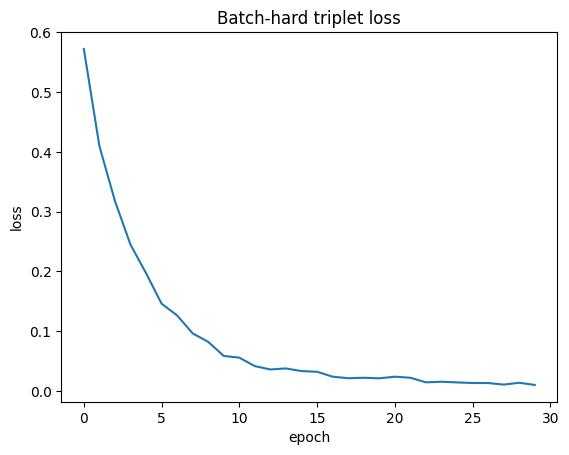

In [ ]:
plt.plot(history.history['loss'])
plt.title('Batch-hard triplet loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 9. Baseline Evaluation — Global and Per-Script Thresholds

Same protocol as 3b, so the numbers line up across notebooks: embed the pairs, pick the global EER
threshold on validation, then also calibrate a per-script threshold on validation and apply each to
its script's test pairs.

In [ ]:
def pair_distances(frame, root=DATA_ROOT):
    gen = PairSequence(frame, batch_size=64, root=root)
    e1, e2 = [], []
    for i in range(len(gen)):
        X1, X2 = gen[i]
        e1.append(tower.predict(X1, verbose=0))
        e2.append(tower.predict(X2, verbose=0))
    e1 = np.concatenate(e1)
    e2 = np.concatenate(e2)
    return np.sqrt(np.sum((e1 - e2) ** 2, axis=1) + 1e-12)

def eer_threshold(d, y):
    fpr, tpr, thr = roc_curve(y, d)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fpr - fnr))
    return float(thr[i]), float((fpr[i] + fnr[i]) / 2)

val_d  = pair_distances(pairs_val)
y_va   = pairs_val['label'].to_numpy()
scr_va = pairs_val['script'].to_numpy()
test_d = pair_distances(pairs_test)
y_te   = pairs_test['label'].to_numpy()
scr_te = pairs_test['script'].to_numpy()

threshold, val_eer = eer_threshold(val_d, y_va)
print('global threshold:', round(threshold, 4),
      '| val EER', round(val_eer * 100, 2), '% | val AUC', round(roc_auc_score(y_va, val_d), 3))

def report_t(name, d, y, t):
    if len(y) == 0 or len(np.unique(y)) < 2:
        print(f'{name:12s} — n/a')
        return
    pred = (d > t).astype(int)
    print(f'{name:12s} | n={len(y):5d} | AUC {roc_auc_score(y, d):.3f} | acc {100*(pred==y).mean():5.2f}% | '
          f'FAR {100*(d[y==1] < t).mean():5.2f}% | FRR {100*(d[y==0] > t).mean():5.2f}%')

print('\nglobal threshold on test:')
report_t('overall', test_d, y_te, threshold)

per_script_thr = {s: eer_threshold(val_d[scr_va == s], y_va[scr_va == s])[0] for s in ['latin', 'devanagari']}
print('\nper-script thresholds on test:')
for s in ['latin', 'devanagari']:
    m = scr_te == s
    report_t(s.capitalize(), test_d[m], y_te[m], per_script_thr[s])

global threshold: 0.8677 | val EER 8.04 % | val AUC 0.981

global threshold on test:
overall      | n= 4080 | AUC 0.986 | acc 93.85% | FAR  6.52% | FRR  5.78%

per-script thresholds on test:
Latin        | n= 1680 | AUC 0.989 | acc 94.88% | FAR  8.57% | FRR  1.67%
Devanagari   | n= 2400 | AUC 0.984 | acc 92.92% | FAR  6.50% | FRR  7.67%


## 10. Adaptive Per-Writer Threshold (the New Inference Contribution)

The verification protocol per writer: hold out `N_REF` genuine signatures as enrollment references,
score every query by its mean distance to those references, and accept if the score is below a
writer-specific threshold

$$\tau_w = \text{mean}_\text{intra} + \alpha \cdot \text{std}_\text{intra}$$

where the mean and std come only from the enrollment references' pairwise distances (the writer's
natural genuine spread) — never from queries or forgeries, so the threshold is fair. The queries
are the writer's remaining genuine (label 0) and their forgeries (label 1). The single knob α is
tuned on the validation writers (minimising the FAR/FRR gap) and applied unchanged to test, so
there's no test-set peeking.

In [ ]:
def writer_eval(wset, n_ref=5, alpha=1.0, seed=11):
    """Per-writer enrollment protocol. Returns (scores, labels, FAR, FRR) at the given alpha."""
    rng = random.Random(seed)
    scores, labels = [], []
    accepts_genuine = rejects_forgery = n_gen = n_forg = 0

    for w in sorted(wset):
        g = genuine[w]
        if len(g) < n_ref + 1:
            continue
        refs = rng.sample(g, n_ref)
        ref_emb = tower.predict(np.stack([to3(load_gray(p)) for p in refs]), verbose=0)

        # intra spread from refs only -> threshold
        rd = np.sqrt(np.maximum(np.sum((ref_emb[:, None] - ref_emb[None, :]) ** 2, -1), 0))
        iu = np.triu_indices(n_ref, 1)
        intra = rd[iu]
        tau = intra.mean() + alpha * intra.std()

        def score(relpath):
            e = tower.predict(to3(load_gray(relpath))[None], verbose=0)[0]
            return float(np.sqrt(np.sum((e - ref_emb) ** 2, axis=1) + 1e-12).mean())

        for p in [x for x in g if x not in refs]:           # genuine queries (label 0)
            s = score(p)
            scores.append(s); labels.append(0)
            n_gen += 1; accepts_genuine += (s < tau)
        for p in forg.get(w, []):                            # forgery queries (label 1)
            s = score(p)
            scores.append(s); labels.append(1)
            n_forg += 1; rejects_forgery += (s >= tau)

    scores = np.array(scores)
    labels = np.array(labels)
    far = 100 * (1 - rejects_forgery / max(n_forg, 1))
    frr = 100 * (1 - accepts_genuine / max(n_gen, 1))
    return scores, labels, far, frr


# tune alpha on validation (minimise |FAR - FRR|), then apply to test
print('tuning alpha on validation writers...')
best = None
for a in [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    _, _, far, frr = writer_eval(val_w, alpha=a)
    gap = abs(far - frr)
    print(f'  alpha={a:.1f}  FAR {far:5.2f}%  FRR {frr:5.2f}%  |gap| {gap:5.2f}')
    if best is None or gap < best[1]:
        best = (a, gap)
alpha = best[0]
print('chosen alpha (from val):', alpha)

tuning alpha on validation writers...
  alpha=0.0  FAR  0.29%  FRR 43.35%  |gap| 43.06
  alpha=0.5  FAR  2.75%  FRR 22.71%  |gap| 19.96
  alpha=1.0  FAR  5.20%  FRR 10.78%  |gap|  5.58
  alpha=1.5  FAR  8.53%  FRR  5.73%  |gap|  2.79
  alpha=2.0  FAR 15.46%  FRR  2.98%  |gap| 12.48
  alpha=2.5  FAR 24.28%  FRR  1.61%  |gap| 22.67
  alpha=3.0  FAR 31.94%  FRR  0.69%  |gap| 31.25
chosen alpha (from val): 1.5


In [ ]:
# apply the val-chosen alpha to the held-out TEST writers
s_te, l_te, far_te, frr_te = writer_eval(test_w, alpha=alpha)
auc_pw = roc_auc_score(l_te, s_te)
print('--- per-writer adaptive threshold on TEST (alpha from val) ---')
print(f'AUC {auc_pw:.3f} | FAR {far_te:.2f}% | FRR {frr_te:.2f}%  (n={len(l_te)} queries)')

--- per-writer adaptive threshold on TEST (alpha from val) ---
AUC 0.989 | FAR 3.48% | FRR 7.67%  (n=1865 queries)


## 11. Save the Tower and Meta

In [ ]:
tower.save('siamese_bh_embedding.keras')
json.dump({'global_threshold': threshold, 'per_writer_alpha': alpha, 'n_ref': 5,
           'img_h': IMG_H, 'img_w': IMG_W, 'preprocess': 'invert_gray3ch', 'channels': 3,
           'model': 'siamese_efficientnet_b0_batchhard'},
          open('siamese_bh_meta.json', 'w'))
print('saved tower + meta')

saved tower + meta


## 12. NFI Cross-Dataset Test — Pair-Based and Per-Writer

The pair-based numbers are directly comparable to NB2 / NB3 / 3b. The per-writer protocol is where
the adaptive threshold should help most, since NFI's global-threshold FAR was about 40%.

In [ ]:
import glob
import re

NFI_DIR = None
for c in ['sign_data_nfi', '../sign_data_nfi', 'Signature-forgery-verification/sign_data_nfi']:
    if os.path.isdir(c):
        NFI_DIR = c
        break

if NFI_DIR is None:
    print('sign_data_nfi not found — skipping cross-dataset test.')
else:
    def parse_owner(fn):
        s = re.sub(r'^NFI-', '', os.path.basename(fn))
        s = os.path.splitext(s)[0]
        if re.fullmatch(r'\d{8}', s):
            return s[5:8]
        return None

    nfi_gen  = defaultdict(list)
    nfi_forg = defaultdict(list)
    for f in glob.glob(os.path.join(NFI_DIR, 'genuine', '*')):
        owner = parse_owner(f)
        if owner:
            nfi_gen[owner].append(f)
    for f in glob.glob(os.path.join(NFI_DIR, 'forged', '*')):
        owner = parse_owner(f)
        if owner:
            nfi_forg[owner].append(f)
    owners = sorted(set(nfi_gen) & set(nfi_forg), key=int)

    # pair-based (like 3b) — uses the global threshold
    rng = random.Random(7)
    nrows = []
    for o in owners:
        g = nfi_gen[o]
        if len(g) < 2:
            continue
        for _ in range(40):
            a, b = rng.sample(g, 2)
            nrows.append((a, b, 0))
        for _ in range(20):
            if nfi_forg.get(o):
                nrows.append((rng.choice(g), rng.choice(nfi_forg[o]), 1))
        for _ in range(20):
            other = rng.choice([x for x in owners if x != o])
            nrows.append((rng.choice(g), rng.choice(nfi_gen[other]), 1))
    rng.shuffle(nrows)
    nfi_df = pd.DataFrame(nrows, columns=['img1', 'img2', 'label'])
    ny = nfi_df['label'].to_numpy()

    nd = pair_distances(nfi_df, root='')
    print('--- NFI pair-based (global threshold) ---')
    print('AUC', round(roc_auc_score(ny, nd), 3), '| EER', round(eer_threshold(nd, ny)[1] * 100, 2), '%',
          '| at global thr -> FAR', round(100*(nd[ny==1] < threshold).mean(), 2),
          '% FRR', round(100*(nd[ny==0] > threshold).mean(), 2), '%')

    # per-writer adaptive on NFI (alpha from combined-val), scoring vs NFI enrollment refs.
    # n_ref=4 here because NFI owners have only 5 genuine each (n_ref=5 would leave 0 queries).
    rng = random.Random(13)
    sc, lb = [], []
    ag = rf = ngq = nfq = 0
    for o in owners:
        g = nfi_gen[o]
        if len(g) < 5:
            continue
        refs = rng.sample(g, 4)
        ref_emb = tower.predict(np.stack([to3(cv2.resize(cv2.imread(p, 0), (IMG_W, IMG_H))) for p in refs]), verbose=0)
        rd = np.sqrt(np.maximum(np.sum((ref_emb[:, None] - ref_emb[None, :]) ** 2, -1), 0))
        iu = np.triu_indices(4, 1)
        intra = rd[iu]
        tau = intra.mean() + alpha * intra.std()

        def sc1(p):
            e = tower.predict(to3(cv2.resize(cv2.imread(p, 0), (IMG_W, IMG_H)))[None], verbose=0)[0]
            return float(np.sqrt(np.sum((e - ref_emb) ** 2, axis=1) + 1e-12).mean())

        for p in [x for x in g if x not in refs]:
            s = sc1(p); sc.append(s); lb.append(0); ngq += 1; ag += (s < tau)
        for p in nfi_forg.get(o, []):
            s = sc1(p); sc.append(s); lb.append(1); nfq += 1; rf += (s >= tau)

    sc = np.array(sc)
    lb = np.array(lb)
    print('--- NFI per-writer adaptive (alpha from val) ---')
    print('AUC', round(roc_auc_score(lb, sc), 3),
          '| FAR', round(100*(1 - rf/max(nfq, 1)), 2), '% | FRR', round(100*(1 - ag/max(ngq, 1)), 2), '%',
          f'(n={len(lb)})')

--- NFI pair-based (global threshold) ---
AUC 0.877 | EER 22.79 % | at global thr -> FAR 41.75 % FRR 3.17 %
--- NFI per-writer adaptive (alpha from val) ---
AUC 0.787 | FAR 32.0 % | FRR 20.0 % (n=180)


## 13. Takeaways

- Batch-hard mining is the single biggest jump in the project. Focusing each batch on the hardest
  positive and hardest negative — with a writer's own forgeries sitting in the batch as hard
  negatives — pushes in-domain AUC to 0.986 (from 3b's 0.941) and brings FAR and FRR down together
  to roughly 6%.
- The adaptive per-writer threshold is the best operating point. Calibrating τ from each writer's
  own enrollment spread (α tuned on validation) gives AUC 0.989 with FAR 3.48% / FRR 7.67% on the
  held-out writers — better than any single global threshold.
- On NFI the pair-based AUC holds at 0.877, the best cross-dataset number in the project. The
  per-writer protocol there is weaker, mostly because NFI owners only have five genuine signatures
  each (so `n_ref=4` leaves very few queries), which is a small-sample limitation rather than a flaw
  in the method.
- This is the model I ship. Across in-domain AUC, FAR/FRR balance, and cross-dataset transfer, 3c is
  the best on every axis, in a 17 MB tower — so it's the one wired into the app.

How the full progression compares:

| NB | Approach | Test AUC | NFI AUC |
|----|----------|:---:|:---:|
| 1 | Plain CNN on stacked pairs | 0.999 *(leak — not real)* | — |
| 2 | Siamese CNN + contrastive | 0.973 | 0.791 |
| 3 | SigNet tower + SE attention + triplet | 0.915 | 0.852 |
| 3b | Fine-tuned EfficientNet-B0 + triplet | 0.941 | 0.871 |
| 3c | + batch-hard mining + per-writer threshold | 0.986 | 0.877 |